  NameFirst CountryCode Continent_Name                              Game  \
0     Peter          DK         Europe  Counter-Strike: Global Offensive   
1   Andreas          DK         Europe  Counter-Strike: Global Offensive   
2   Nicolai          DK         Europe  Counter-Strike: Global Offensive   

                  Genre  TeamBasedGame  
0  First-Person Shooter              1  
1  First-Person Shooter              1  
2  First-Person Shooter              1  


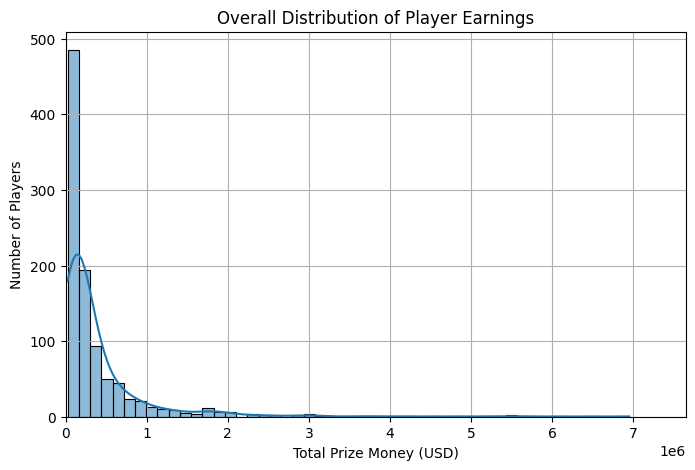

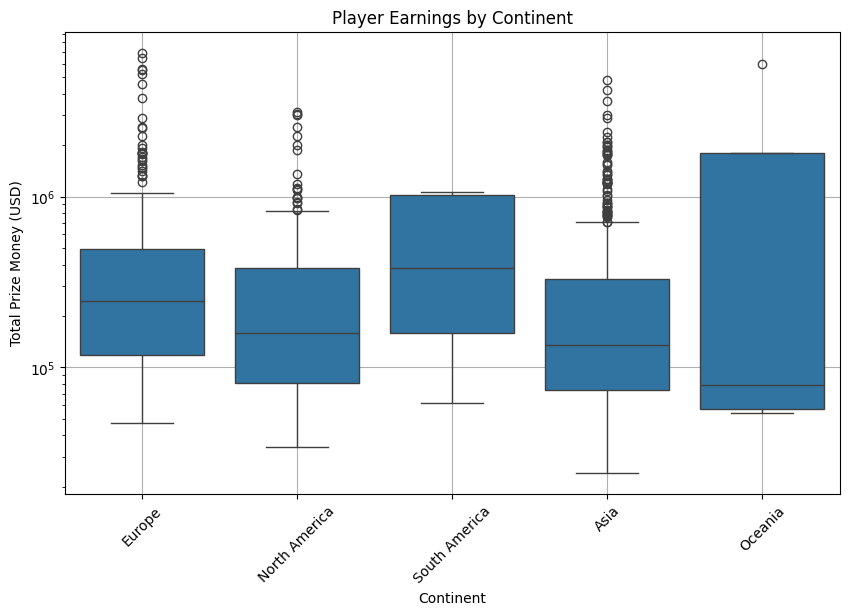

In [13]:
import pandas as pd

players_df = pd.read_csv('archive\highest_earning_players.csv')
teams_df   = pd.read_csv('archive\highest_earning_teams.csv')
country_df = pd.read_csv('archive\country-and-continent-codes-list.csv')

players_df['CountryCode'] = players_df['CountryCode'].str.upper()  # normalize case
country_df = country_df.drop_duplicates(subset=['Two_Letter_Country_Code'], keep='first')
players_df = players_df.merge(country_df[['Two_Letter_Country_Code','Country_Name','Continent_Name']],
                               left_on='CountryCode', right_on='Two_Letter_Country_Code', how='left')

team_genres = ['First-Person Shooter', 'Multiplayer Online Battle Arena', 'Third-Person Shooter']
players_df['TeamBasedGame'] = players_df['Genre'].apply(lambda g: 1 if g in team_genres else 0)

#sanity check
print(players_df[['NameFirst','CountryCode','Continent_Name','Game','Genre','TeamBasedGame']].head(3))

import matplotlib.pyplot as plt
import seaborn as sns

# Plot overall distribution of earning
plt.figure(figsize=(8, 5))
sns.histplot(players_df['TotalUSDPrize'], bins=50, kde=True)
plt.title('Overall Distribution of Player Earnings')
plt.xlabel('Total Prize Money (USD)')
plt.ylabel('Number of Players')
plt.xlim(0, players_df['TotalUSDPrize'].max() * 1.1)  # Slightly expand x-axis
plt.grid(True)
plt.show()


# Plot earnings distribution by continent
plt.figure(figsize=(10, 6))
sns.boxplot(data=players_df, x='Continent_Name', y='TotalUSDPrize')
plt.title('Player Earnings by Continent')
plt.xlabel('Continent')
plt.ylabel('Total Prize Money (USD)')
plt.yscale('log')  #log scale to better visualize different magnitudes
plt.grid(True)
plt.xticks(rotation=45) 
plt.show()

R² score on training data: 0.5835745594766047
Top 10 coefficients by magnitude:
 CountryCode_LB    2.218412e+06
CountryCode_PK    1.633317e+06
Game_Dota 2       1.618312e+06
CountryCode_JO    1.190871e+06
CountryCode_MK   -9.283108e+05
CountryCode_BY   -8.745824e+05
CountryCode_PH   -7.938415e+05
CountryCode_MY   -6.699031e+05
CountryCode_AU    6.508571e+05
CountryCode_MO   -6.376922e+05
dtype: float64


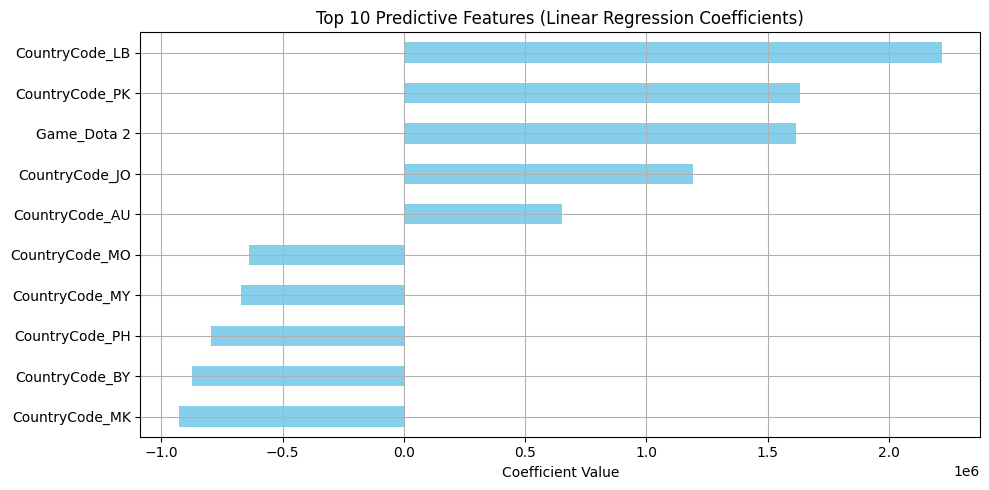

d:\320\.venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.122e+13, tolerance: 3.876e+10
  model = cd_fast.enet_coordinate_descent(


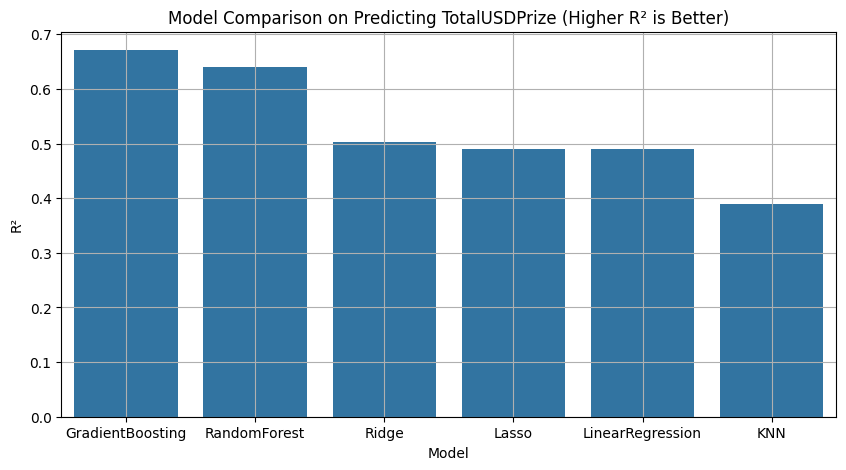

In [14]:
from sklearn.linear_model import LinearRegression
import pandas as pd

#design matrix X and target y
# We'll use CountryCode and Game as categorical predictors
X = pd.get_dummies(players_df[['CountryCode', 'Game']], drop_first=True)  # One-hot encoding
y = players_df['TotalUSDPrize']

model = LinearRegression()
model.fit(X, y)

print("R² score on training data:", model.score(X, y)) 

#top coefficients
coefs = pd.Series(model.coef_, index=X.columns)
top_feats = coefs.reindex(coefs.abs().sort_values(ascending=False).index[:10])
print("Top 10 coefficients by magnitude:\n", top_feats)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
top_feats.sort_values().plot(kind='barh', color='skyblue')
plt.title('Top 10 Predictive Features (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.grid(True)
plt.tight_layout()
plt.show()


from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso
import numpy as np

X = pd.get_dummies(players_df[['CountryCode', 'Game']], drop_first=True)
y = players_df['TotalUSDPrize']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model compare
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=0),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=0),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MSE': mse, 'R²': r2})

results_df = pd.DataFrame(results)
results_df.sort_values(by='R²', ascending=False, inplace=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(x='Model', y='R²', data=results_df)
plt.title('Model Comparison on Predicting TotalUSDPrize (Higher R² is Better)')
plt.grid(True)
plt.show()


Cluster centers (approx):
 [[1.59277236e+05 3.33066907e-16]
 [6.58798842e+05 9.96551724e-01]
 [8.60873029e+04 1.00000000e+00]]
Cluster sizes:
 Cluster
0    399
2    311
1    290
Name: count, dtype: int64


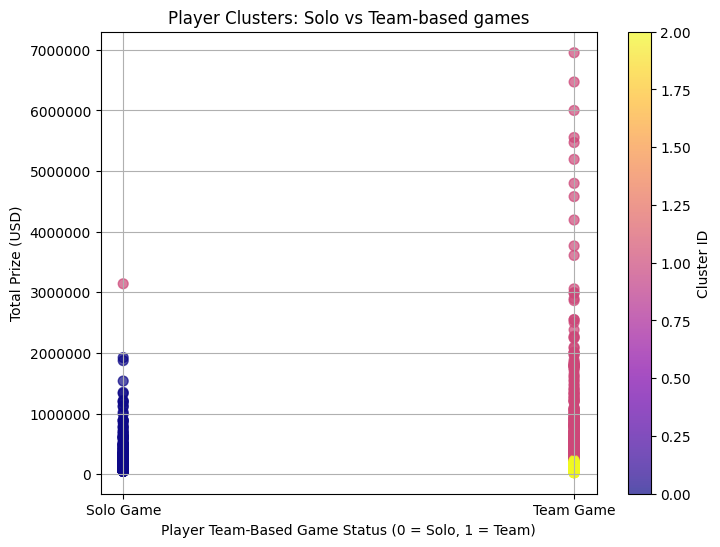

In [15]:
from sklearn.cluster import KMeans
import numpy as np

player_features = players_df.copy()
player_features['LogPrize'] = np.log10(player_features['TotalUSDPrize'] + 1)

# Features for clustering: LogPrize and TeamBasedGame
X_player = player_features[['LogPrize', 'TeamBasedGame']]

#Apply KMeans
kmeans_player = KMeans(n_clusters=3, random_state=0)
player_features['Cluster'] = kmeans_player.fit_predict(X_player)

# Examine Cluster Centers
centers = kmeans_player.cluster_centers_
centers[:, 0] = 10**centers[:, 0] - 1  # convert log-prize center back to prize dollars
print("Cluster centers (approx):\n", centers)
print("Cluster sizes:\n", player_features['Cluster'].value_counts())

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    player_features['TeamBasedGame'], 
    player_features['TotalUSDPrize'], 
    c=player_features['Cluster'], 
    cmap='plasma',    # Color by cluster
    s=50, 
    alpha=0.7
)

plt.title('Player Clusters: Solo vs Team-based games')
plt.xlabel('Player Team-Based Game Status (0 = Solo, 1 = Team)')
plt.ylabel('Total Prize (USD)')
plt.colorbar(scatter, label='Cluster ID')
plt.xticks([0, 1], ['Solo Game', 'Team Game'])
plt.ticklabel_format(style='plain', axis='y')  
plt.grid(True)
plt.show()

Cluster centers (approx):
 [[1.59277236e+05 3.33066907e-16]
 [6.58798842e+05 9.96551724e-01]
 [8.60873029e+04 1.00000000e+00]]
Cluster sizes: Cluster
0    399
2    311
1    290
Name: count, dtype: int64
                 TeamName  TotalTournaments  TotalUSDPrize  Cluster
0     San Francisco Shock                 7     3105000.00        0
1         London Spitfire                13     1591136.50        0
2      New York Excelsior                18     1572618.50        0
3     Philadelphia Fusion                15     1186278.50        0
4           Seoul Dynasty                 6     1130000.00        3
5        Vancouver Titans                 4      950000.00        3
6        Shanghai Dragons                 5      755000.00        3
7  Los Angeles Gladiators                13      709605.19        3
8           Atlanta Reign                 9      596098.00        3
9     Los Angeles Valiant                 6      535000.00        3


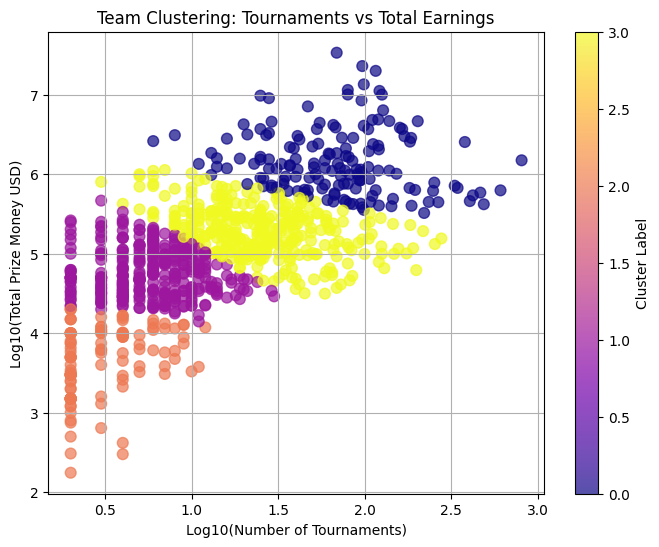

In [16]:
from sklearn.cluster import KMeans
import numpy as np

# Features for clustering: log10 of prize and team-game flag
player_features = players_df.copy()
player_features['LogPrize'] = np.log10(player_features['TotalUSDPrize'] + 1)
X_player = player_features[['LogPrize','TeamBasedGame']]

kmeans_player = KMeans(n_clusters=3, random_state=0)
player_features['Cluster'] = kmeans_player.fit_predict(X_player)

centers = kmeans_player.cluster_centers_
centers[:,0] = 10**centers[:,0] - 1 
print("Cluster centers (approx):\n", centers)
print("Cluster sizes:", player_features['Cluster'].value_counts())


team_features = teams_df.copy()
team_features['LogPrize'] = np.log10(team_features['TotalUSDPrize'] + 1)
team_features['LogTourn'] = np.log10(team_features['TotalTournaments'] + 1)

kmeans_team = KMeans(n_clusters=4, random_state=0)
team_features['Cluster'] = kmeans_team.fit_predict(team_features[['LogTourn','LogPrize']])
print(team_features[['TeamName','TotalTournaments','TotalUSDPrize','Cluster']].head(10))

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    team_features['LogTourn'], 
    team_features['LogPrize'], 
    c=team_features['Cluster'], 
    cmap='plasma',  # Color by cluster
    alpha=0.7,
    s=60
)

plt.title('Team Clustering: Tournaments vs Total Earnings')
plt.xlabel('Log10(Number of Tournaments)')
plt.ylabel('Log10(Total Prize Money USD)')
plt.colorbar(scatter, label='Cluster Label')
plt.grid(True)
plt.show()